<a href="https://colab.research.google.com/github/patriciasandagorda/AST/blob/main/AST_Clase_4_ejercicio_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div class="alert alert-block alert-info">
    <h1>Análisis de Series Temporales</h1>
    <h3>Clase 3</h3>
    <h5>Ejercicio 3 - prueba con datos sinteticos</h5>
        <p>Docente: Rodrigo Del Rosso<p>
        <p>Asistentes: Sebastián Calcagno y Braian Drago<p>
</div>

Aca trabajamos con cointegracion que vimos en las presentaciones. Primero generamos dos series no estacionarias que se mueven juntas en el largo plazo, desp estimamos esa relacion mediante una regresion y usamos sus residuos para medir q tan alejadas estan del equilibrio. Para terminar construimos un modelo de correccion de errores, donde el cambio de Y depende tanto del cambio de X en el corto plazo como del desequilibrio del período anterior.
Asi trabajamos con una introduccion de VECM ( Modelo Vectorial de Correccion de Errores. )

In [ ]:
# Importamos librerias

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt


In [ ]:
# Crear datos sintéticos cointegrados

# Supongamos que tenemos dos series cointegradas

np.random.seed(42)
n = 100

# Generamos x_t como un paseo aleatorio
x = np.cumsum(np.random.normal(0, 1, n))

# Generamos y_t como x_t más un poco de ruido
y = x + np.random.normal(0, 1, n)

# Crear DataFrame
data = pd.DataFrame({'y': y, 'x': x})


In [ ]:
# Estimar la relación a largo plazo (cointegración)

# Primero hacemos una regresión OLS para obtener el residuo 𝑢𝑡 = 𝑦𝑡 − 𝛽𝑥𝑡, que servirá como término de corrección de error:

# Agregar constante
X = sm.add_constant(data['x'])
ols = sm.OLS(data['y'], X).fit()
print(ols.summary())

# Residuo (error de cointegración)
data['resid'] = ols.resid


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.959
Model:                            OLS   Adj. R-squared:                  0.959
Method:                 Least Squares   F-statistic:                     2316.
Date:                Thu, 21 Aug 2025   Prob (F-statistic):           5.35e-70
Time:                        12:34:38   Log-Likelihood:                -136.64
No. Observations:                 100   AIC:                             277.3
Df Residuals:                      98   BIC:                             282.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0115      0.164      0.070      0.9

Construir el ECM

El ECM se basa en la idea:

Δ𝑦𝑡 = 𝛼 + 𝛽Δ𝑡 + 𝛾 (𝑦𝑡−1−𝛽𝑥𝑡−1)+𝜖𝑡​


Donde:

Δ𝑦𝑡=𝑦𝑡−𝑦𝑡−1
Δ𝑥𝑡=𝑥𝑡−𝑥𝑡−1
(𝑦𝑡−1−𝛽𝑥𝑡−1)es el término de corrección de error.

In [ ]:
# Diferencias
data['dy'] = data['y'].diff()
data['dx'] = data['x'].diff()
data['lag_resid'] = data['resid'].shift(1)

# Eliminamos primer valor nulo
data_ecm = data.dropna()

# Variables dependiente e independiente
X_ecm = sm.add_constant(data_ecm[['dx', 'lag_resid']])
y_ecm = data_ecm['dy']

# Estimamos ECM
ecm_model = sm.OLS(y_ecm, X_ecm).fit()
print(ecm_model.summary())


                            OLS Regression Results                            
Dep. Variable:                     dy   R-squared:                       0.691
Model:                            OLS   Adj. R-squared:                  0.684
Method:                 Least Squares   F-statistic:                     107.1
Date:                Thu, 21 Aug 2025   Prob (F-statistic):           3.53e-25
Time:                        12:35:04   Log-Likelihood:                -133.17
No. Observations:                  99   AIC:                             272.3
Df Residuals:                      96   BIC:                             280.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0006      0.095     -0.006      0.9

In [ ]:
# Predicción de Δy_t con el ECM
data_ecm['dy_pred'] = ecm_model.predict(X_ecm)

# Reconstruimos y_t a partir de Δy
data_ecm['y_pred'] = data_ecm['y'].iloc[0] + data_ecm['dy_pred'].cumsum()


/tmp/ipython-input-2114730664.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_ecm['dy_pred'] = ecm_model.predict(X_ecm)
/tmp/ipython-input-2114730664.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_ecm['y_pred'] = data_ecm['y'].iloc[0] + data_ecm['dy_pred'].cumsum()


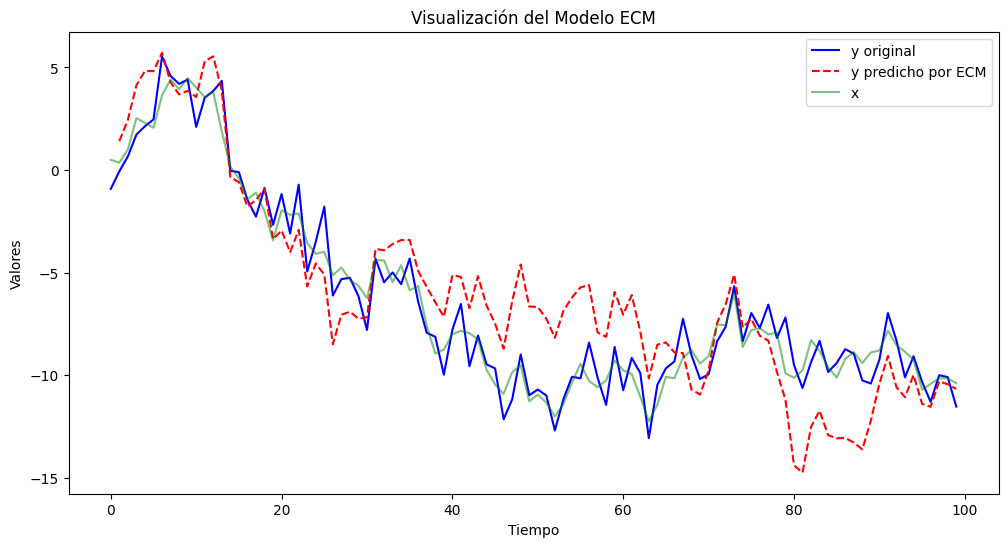

In [ ]:
plt.figure(figsize=(12,6))

# Serie original
plt.plot(data['y'], label='y original', color='blue')
# Serie simulada con ECM
plt.plot(data_ecm.index, data_ecm['y_pred'], label='y predicho por ECM', color='red', linestyle='--')
# Serie x (escala similar para comparación)
plt.plot(data['x'], label='x', color='green', alpha=0.5)

plt.title('Visualización del Modelo ECM')
plt.xlabel('Tiempo')
plt.ylabel('Valores')
plt.legend()
plt.show()


En este gráfico podrás ver:

La línea azul: valores reales de 𝑦𝑡.

La línea roja punteada: cómo el ECM ajusta yt
 hacia el equilibrio con
𝑥
𝑡
x
t
	​

.

La línea verde:
𝑥
𝑡
x
t
	​

 como referencia de la relación de largo plazo.